In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

from src.utils import (
    anomalies,
    area_weighted_mean,
    coarsen_to_4deg,
    composite,
    detect_events,
    interp_to_4deg,
    linear_trend,
    load_sst,
    monthly_climatology,
    rolling_index,
    subset_region,
)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(exist_ok=True)

# Load NOAA ERSST v6 and calculate monthly anomalies against 1991-2020.
ds = load_sst()
sst = ds["sst"]
global_climatology = monthly_climatology(sst)
anom_field = anomalies(sst, global_climatology)
print(ds)
print(f"Anomaly period: {anom_field.time.min().dt.strftime('%Y-%m').item()} to {anom_field.time.max().dt.strftime('%Y-%m').item()}")

<xarray.Dataset> Size: 136MB
Dimensions:  (time: 2120, lat: 89, lon: 180)
Coordinates:
  * time     (time) datetime64[ns] 17kB 1850-01-01 1850-02-01 ... 2026-08-01
  * lat      (lat) float32 356B 88.0 86.0 84.0 82.0 ... -82.0 -84.0 -86.0 -88.0
  * lon      (lon) float32 720B 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
Data variables:
    sst      (time, lat, lon) float32 136MB ...
Attributes: (12/39)
    climatology:               Climatology is based on 1971-2000 SST, Xue, Y....
    description:               In situ data: ICOADS2.5 before 2007 and NCEP i...
    keywords_vocabulary:       NASA Global Change Master Directory (GCMD) Sci...
    keywords:                  Earth Science > Oceans > Ocean Temperature > S...
    instrument:                Conventional thermometers
    source_comment:            SSTs were observed by conventional thermometer...
    ...                        ...
    product_version:           Version 6
    history:                   created 01/16/2025 by P

In [2]:
# Build the Niño 3.4-style area-averaged index from 5N-5S, 170W-120W.
enso_region = subset_region(sst, lat_bounds=(-5, 5), lon_bounds=(190, 240))
enso_anomalies = anomalies(enso_region, monthly_climatology(enso_region))
anomaly_index = area_weighted_mean(enso_anomalies)
rolling_anomaly = rolling_index(anomaly_index)
events = detect_events(rolling_anomaly)

index_table = xr.Dataset(
    {"anomaly": anomaly_index, "rolling_anomaly": rolling_anomaly}
).to_dataframe().reset_index()[["time", "anomaly", "rolling_anomaly"]]
index_table.to_csv(RESULTS_DIR / "enso_index.csv", index=False)

warm_months = sorted(
    set(
        month
        for event in events["warm"]
        for month in pd.date_range(event["start"], event["end"], freq="MS")
    )
)
cold_months = sorted(
    set(
        month
        for event in events["cold"]
        for month in pd.date_range(event["start"], event["end"], freq="MS")
    )
)

print(f"Exported {len(index_table)} monthly index values to {RESULTS_DIR / 'enso_index.csv'}")
print(f"Detected {len(events['warm'])} warm events and {len(events['cold'])} cold events.")

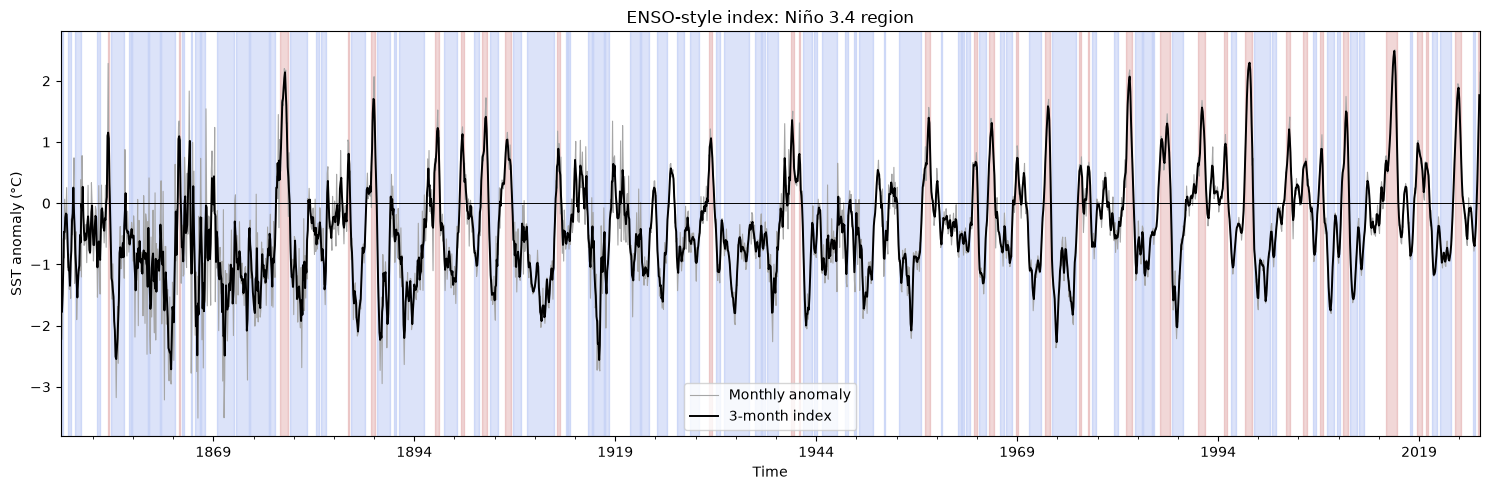

Top three El Niño events by peak magnitude:
{'start': np.datetime64('2014-11-01T00:00:00.000000000'), 'end': np.datetime64('2016-04-01T00:00:00.000000000'), 'peak': 2.4881114959716797}
{'start': np.datetime64('1997-05-01T00:00:00.000000000'), 'end': np.datetime64('1998-04-01T00:00:00.000000000'), 'peak': 2.2949211597442627}
{'start': np.datetime64('1877-05-01T00:00:00.000000000'), 'end': np.datetime64('1878-04-01T00:00:00.000000000'), 'peak': 2.139147996902466}
Top three La Niña events by peak magnitude:
{'start': np.datetime64('1862-07-01T00:00:00.000000000'), 'end': np.datetime64('1864-04-01T00:00:00.000000000'), 'peak': -2.712819814682007}
{'start': np.datetime64('1916-04-01T00:00:00.000000000'), 'end': np.datetime64('1917-08-01T00:00:00.000000000'), 'peak': -2.561296224594116}
{'start': np.datetime64('1856-04-01T00:00:00.000000000'), 'end': np.datetime64('1857-11-01T00:00:00.000000000'), 'peak': -2.5462076663970947}


In [3]:
# Plot the monthly anomaly and centered 3-month ENSO-style index.
fig, ax = plt.subplots(figsize=(15, 5))
index_table.plot(x="time", y="anomaly", ax=ax, color="0.65", linewidth=0.8, label="Monthly anomaly")
index_table.plot(x="time", y="rolling_anomaly", ax=ax, color="black", linewidth=1.4, label="3-month index")

for event in events["warm"]:
    ax.axvspan(event["start"], event["end"], color="firebrick", alpha=0.18)
for event in events["cold"]:
    ax.axvspan(event["start"], event["end"], color="royalblue", alpha=0.18)

ax.axhline(0, color="black", linewidth=0.7)
ax.set_title("ENSO-style index: Niño 3.4 region")
ax.set_ylabel("SST anomaly (°C)")
ax.set_xlabel("Time")
ax.legend()
fig.tight_layout()
plt.show()

warm_top = sorted(events["warm"], key=lambda event: event["peak"], reverse=True)[:3]
cold_top = sorted(events["cold"], key=lambda event: event["peak"])[:3]
print("Top three El Niño events by peak magnitude:")
for event in warm_top:
    print(event)
print("Top three La Niña events by peak magnitude:")
for event in cold_top:
    print(event)

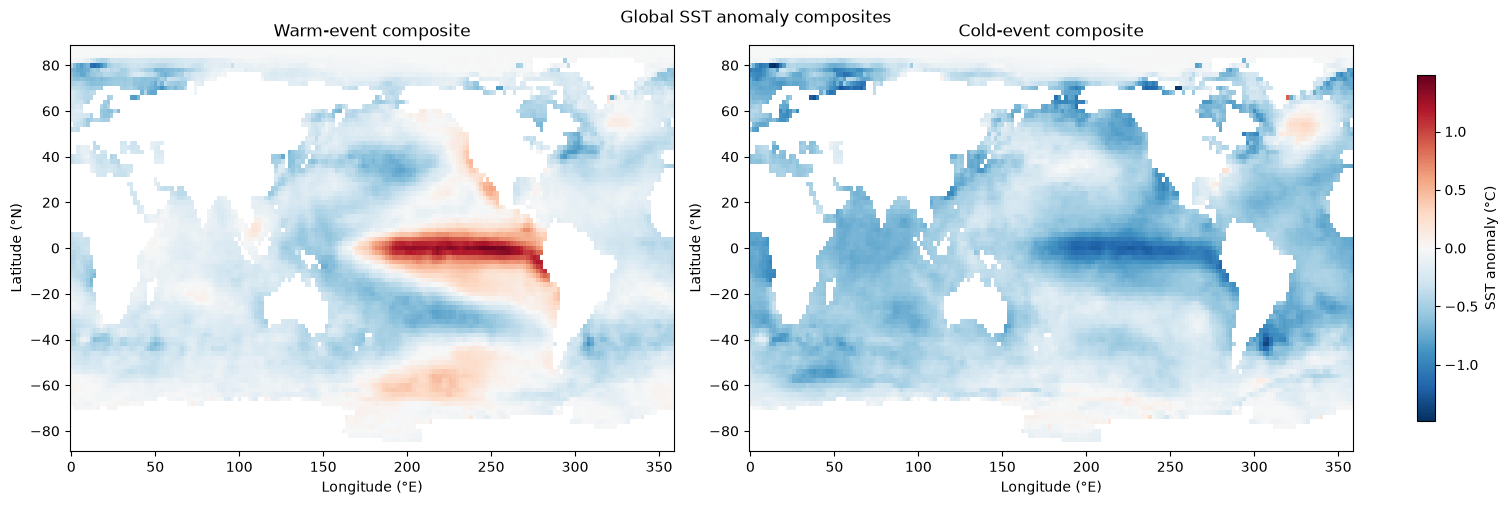

Saved /Users/robmoore/geoanalytics/geog313-assignments/assignment-4/results/composite_warm.nc and /Users/robmoore/geoanalytics/geog313-assignments/assignment-4/results/composite_cold.nc


In [4]:
# Build and export warm and cold spatial composites using the same color scale.
warm_composite = composite(anom_field, warm_months)
cold_composite = composite(anom_field, cold_months)
warm_composite.to_netcdf(RESULTS_DIR / "composite_warm.nc")
cold_composite.to_netcdf(RESULTS_DIR / "composite_cold.nc")

composite_limit = max(
    float(np.abs(warm_composite).max()),
    float(np.abs(cold_composite).max()),
)
fig, axes = plt.subplots(1, 2, figsize=(15, 4.8), constrained_layout=True)
for axis, composite_field, title in zip(
    axes,
    [warm_composite, cold_composite],
    ["Warm-event composite", "Cold-event composite"],
):
    image = composite_field.plot.pcolormesh(
        ax=axis,
        cmap="RdBu_r",
        vmin=-composite_limit,
        vmax=composite_limit,
        add_colorbar=False,
    )
    axis.set_title(title)
    axis.set_xlabel("Longitude (°E)")
    axis.set_ylabel("Latitude (°N)")
fig.colorbar(image, ax=axes, label="SST anomaly (°C)", shrink=0.85)
fig.suptitle("Global SST anomaly composites", y=1.02)
plt.show()

print(f"Saved {RESULTS_DIR / 'composite_warm.nc'} and {RESULTS_DIR / 'composite_cold.nc'}")

### Composite interpretation

The warm-event composite shows the canonical El Niño structure, with positive anomalies concentrated across the central and eastern equatorial Pacific and a peak near 246°E. The cold-event composite reverses this tropical Pacific signal, with strong negative anomalies in the same broad region. Both composites also contain weaker opposite-sign anomalies outside the tropical Pacific, consistent with the atmospheric teleconnections associated with ENSO. These maps are event-conditioned means, so they describe the average spatial pattern rather than the structure of any single event.

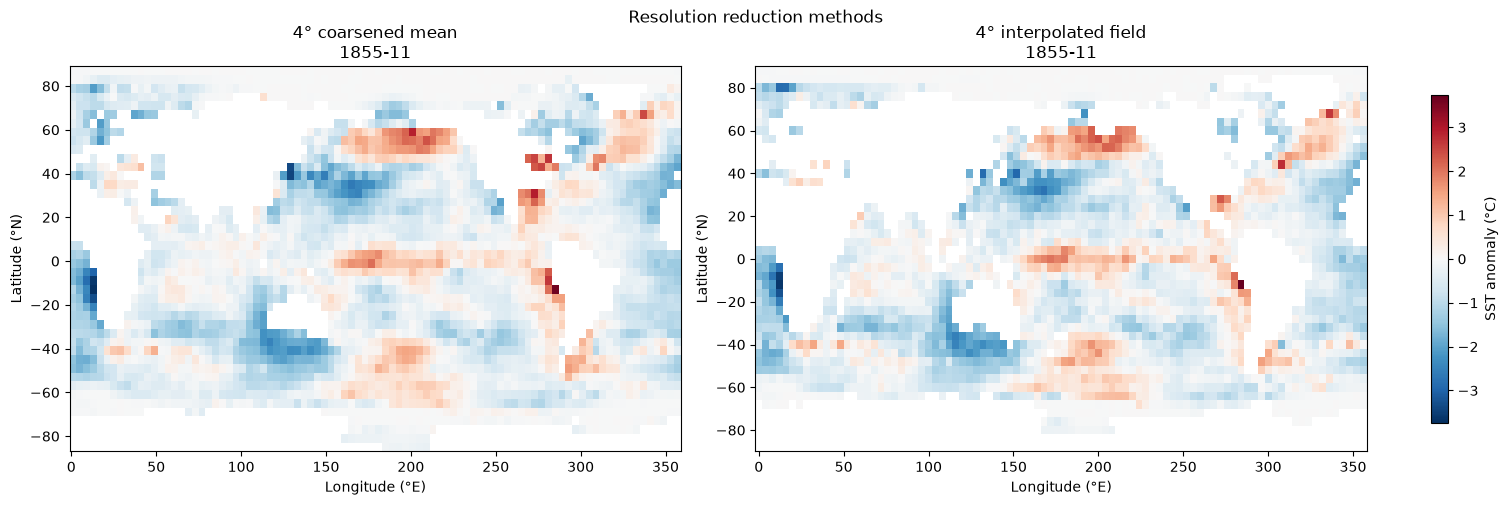

In [5]:
# Compare the two 4-degree representations for one representative event month.
representative_month = warm_months[0] if warm_months else cold_months[0]
representative_field = anom_field.sel(time=representative_month)
coarsened_field = coarsen_to_4deg(representative_field)
interpolated_field = interp_to_4deg(representative_field)
comparison_limit = max(
    float(np.abs(coarsened_field).max()),
    float(np.abs(interpolated_field).max()),
)

fig, axes = plt.subplots(1, 2, figsize=(15, 4.8), constrained_layout=True)
for axis, field, title in zip(
    axes,
    [coarsened_field, interpolated_field],
    ["4° coarsened mean", "4° interpolated field"],
):
    image = field.plot.pcolormesh(
        ax=axis,
        cmap="RdBu_r",
        vmin=-comparison_limit,
        vmax=comparison_limit,
        add_colorbar=False,
    )
    axis.set_title(f"{title}\n{pd.Timestamp(representative_month):%Y-%m}")
    axis.set_xlabel("Longitude (°E)")
    axis.set_ylabel("Latitude (°N)")
fig.colorbar(image, ax=axes, label="SST anomaly (°C)", shrink=0.85)
fig.suptitle("Resolution reduction methods", y=1.02)
plt.show()

### Coarsening versus interpolation

The coarsened map averages each 2° by 2° block, which smooths small-scale extrema and represents the mean anomaly over each 4° cell. The interpolated map samples the continuous field at every second coordinate, so it retains the original grid-point values and can preserve sharper local gradients. Coarsening is generally preferable when the goal is an area-representative reduced-resolution field, while interpolation is useful when a regular target grid is needed without aggregation.

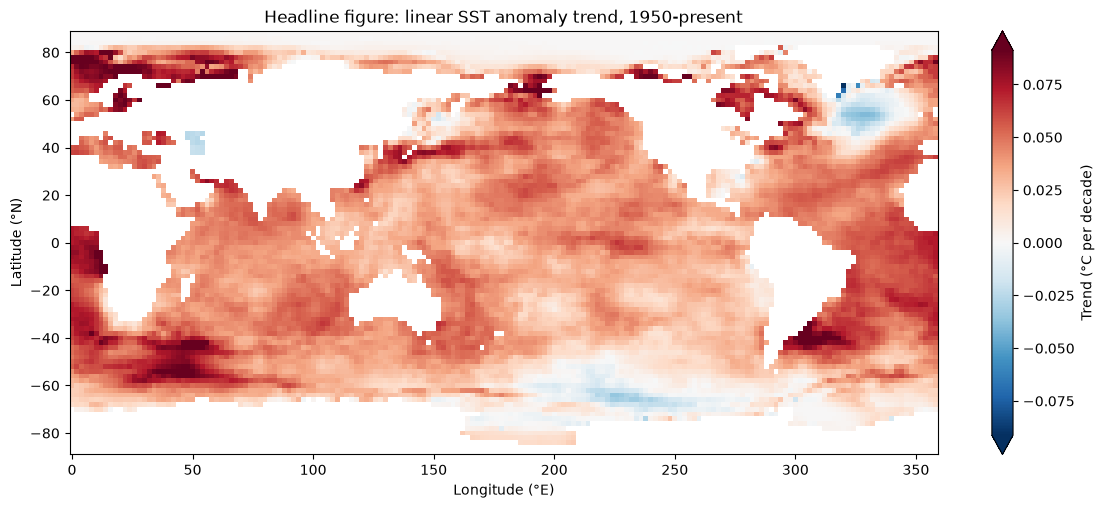

Trend caveats: a linear fit compresses substantial multidecadal variability into one slope and does not establish causation. The estimate is sensitive to the selected period, missing data, and serial correlation, while the 1991-2020 anomaly baseline changes the intercept but not the slope.


In [6]:
# Headline figure: linear SST anomaly trend in °C per decade.
trend_field = linear_trend(anom_field)
trend_limit = float(np.abs(trend_field).quantile(0.99))
fig, axis = plt.subplots(figsize=(14, 5.5))
trend_field.plot.pcolormesh(
    ax=axis,
    cmap="RdBu_r",
    vmin=-trend_limit,
    vmax=trend_limit,
    cbar_kwargs={"label": "Trend (°C per decade)"},
)
axis.set_title("Headline figure: linear SST anomaly trend, 1950-present")
axis.set_xlabel("Longitude (°E)")
axis.set_ylabel("Latitude (°N)")
plt.show()

print(
    "Trend caveats: a linear fit compresses substantial multidecadal variability "
    "into one slope and does not establish causation. The estimate is sensitive "
    "to the selected period, missing data, and serial correlation, while the "
    "1991-2020 anomaly baseline changes the intercept but not the slope."
)

### Trend interpretation and caveats

The trend map should be read as a long-term spatial pattern in SST anomalies relative to the 1991–2020 seasonal baseline, with broad regional warming and localized areas of weaker or negative trend. The strongest values may occur where sparse early observations, changes in sampling, or regional variability influence the fit. A single linear slope also hides multidecadal variability and does not establish a physical cause. Results are sensitive to the analysis period, missing values, serial correlation, and the assumption that one linear trend is an adequate summary.